# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.dummy import DummyClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report






# Importando Dados e Tratando/Padronizando

In [2]:
df = pd.read_csv('/content/dados_tratados.csv')
df

,ID_Cliente,Churn,Genero_Cliente,Senioridade,Tem_Parceiro,Tem_Dependentes,Meses_Cliente,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Mensalidade,Total_Cobrado,Custo_Diario
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,...,False,True,False,False,One year,False,Mailed check,55.15,742.90,1.838333
7039,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,...,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70,2.836667
7040,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75,1.676667
7041,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,...,True,True,False,True,Two year,False,Mailed check,67.85,4627.65,2.261667


In [3]:
df.columns

Index(['ID_Cliente', 'Churn', 'Genero_Cliente', 'Senioridade', 'Tem_Parceiro',
       'Tem_Dependentes', 'Meses_Cliente', 'Servico_Telefone',
       'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online',
       'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico',
       'Streaming_TV', 'Streaming_Filmes', 'Tipo_Contrato', 'Fatura_Digital',
       'Metodo_Pagamento', 'Mensalidade', 'Total_Cobrado', 'Custo_Diario'],
      dtype='object')

In [4]:
df_tratado = df.drop(columns=['ID_Cliente'])
df_tratado

,Churn,Genero_Cliente,Senioridade,Tem_Parceiro,Tem_Dependentes,Meses_Cliente,Servico_Telefone,Multiplas_Linhas,Servico_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Mensalidade,Total_Cobrado,Custo_Diario
0,False,Female,False,True,True,9,True,False,DSL,False,...,False,True,True,False,One year,True,Mailed check,65.60,593.30,2.186667
1,False,Male,False,False,False,9,True,True,DSL,False,...,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40,1.996667
2,True,Male,False,False,False,4,True,False,Fiber optic,False,...,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85,2.463333
3,True,Male,True,True,False,13,True,False,Fiber optic,False,...,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85,3.266667
4,True,Female,True,True,False,3,True,False,Fiber optic,False,...,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,Female,False,False,False,13,True,False,DSL,True,...,False,True,False,False,One year,False,Mailed check,55.15,742.90,1.838333
7039,True,Male,False,True,False,22,True,True,Fiber optic,False,...,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70,2.836667
7040,False,Male,False,False,False,2,True,False,DSL,False,...,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75,1.676667
7041,False,Male,False,True,True,67,True,False,DSL,True,...,True,True,False,True,Two year,False,Mailed check,67.85,4627.65,2.261667


In [5]:

proporcao = df['Churn'].value_counts(normalize=True)
print(proporcao)


Churn
False    0.73463
True     0.26537
Name: proportion, dtype: float64


In [6]:
#One Hot
categorical_cols = ['Genero_Cliente', 'Multiplas_Linhas',
                    'Servico_Internet', 'Tipo_Contrato',
                    'Metodo_Pagamento']

df_encoded = pd.get_dummies(df_tratado, columns=categorical_cols, drop_first=True)

df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})

df_encoded.head()

,Churn,Senioridade,Tem_Parceiro,Tem_Dependentes,Meses_Cliente,Servico_Telefone,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,...,Custo_Diario,Genero_Cliente_Male,Multiplas_Linhas_True,Servico_Internet_Fiber optic,Servico_Internet_No,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0,0,1,1,9,1,0,1,0,1,...,2.186667,0,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0,0,0,0,...,1.996667,1,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,1,0,...,2.463333,1,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,1,1,0,...,3.266667,1,0,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,1,...,2.796667,0,0,1,0,0,0,0,0,1


In [7]:
#Normalização


scaler = StandardScaler()
num_cols = ['Meses_Cliente', 'Mensalidade', 'Total_Cobrado', 'Custo_Diario']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded

,Churn,Senioridade,Tem_Parceiro,Tem_Dependentes,Meses_Cliente,Servico_Telefone,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,...,Custo_Diario,Genero_Cliente_Male,Multiplas_Linhas_True,Servico_Internet_Fiber optic,Servico_Internet_No,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0,0,1,1,-0.951682,1,0,1,0,1,...,0.027862,0,0,0,0,1,0,0,0,1
1,0,0,0,0,-0.951682,1,0,0,0,0,...,-0.161583,1,1,0,0,0,0,0,0,1
2,1,0,0,0,-1.155283,1,0,0,1,0,...,0.303720,1,0,1,0,0,0,0,1,0
3,1,1,1,0,-0.788800,1,0,1,1,0,...,1.104706,1,0,1,0,0,0,0,1,0
4,1,1,1,0,-1.196004,1,0,0,0,1,...,0.636080,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,-0.788800,1,1,0,0,1,...,-0.319454,0,0,0,0,1,0,0,0,1
7039,1,0,1,0,-0.422317,1,0,0,0,0,...,0.675963,1,1,1,0,0,0,0,1,0
7040,0,0,0,0,-1.236724,1,0,1,0,0,...,-0.480648,1,0,0,0,0,0,0,0,1
7041,0,0,1,1,1.410099,1,1,0,1,1,...,0.102643,1,0,0,0,0,1,0,0,1


<Axes: >

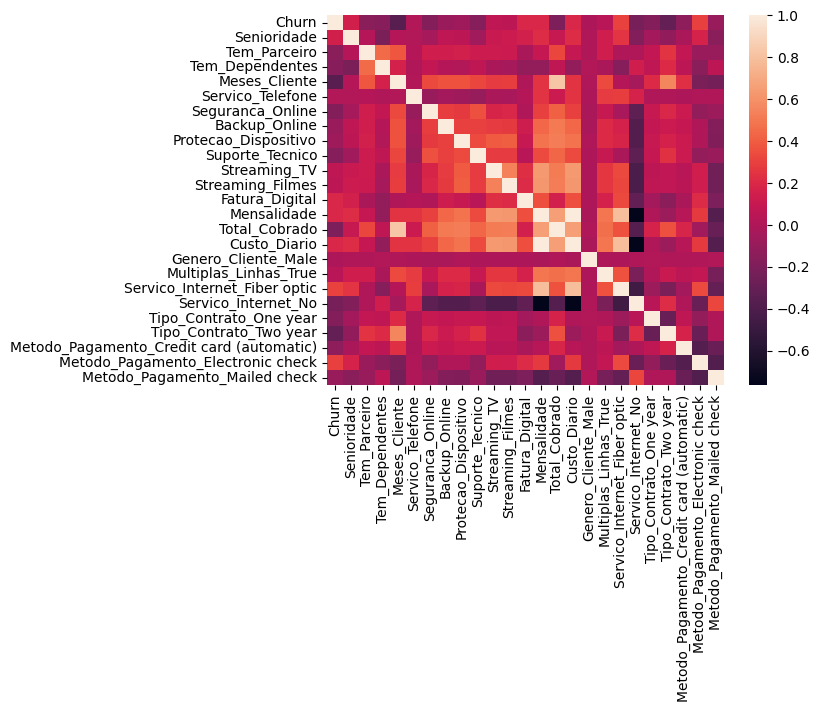

In [8]:
sns.heatmap(df_encoded.corr())

**Variáveis com pouco peso (baixa correlação com churn)**

- Gênero do cliente (genero_cliente_male) → costuma ter correlação muito baixa, quase irrelevante.

- Ter parceiro (tem_parceiro) → impacto pequeno, correlação fraca.

- Ter dependentes (tem_dependentes) → também aparece com correlação baixa.

- Serviço de telefone (servico_telefone) → pouca relação direta com churn.

- Multiplas linhas (multiplas_linhas_true) → geralmente não mostra correlação forte.

- Método de pagamento – cartão automático ou cheque enviado (metodo_pagamento_credit card automatic, metodo_pagamento_mailed check)
→ correlação fraca comparada ao electronic check, que costuma ter maior peso.

**Variáveis com maior peso (mais relevantes para churn)**
- Tipo de contrato (one year, two year) → contratos mais longos reduzem churn.

- Serviço de internet (fiber optic vs. no) → forte relação com evasão.

- Serviços adicionais (segurança online, backup online, proteção de dispositivo, suporte técnico) → ausência desses serviços tende a aumentar churn.

- Mensalidade (mensalidade) e método de pagamento electronic check → costumam ter correlação mais alta com churn.

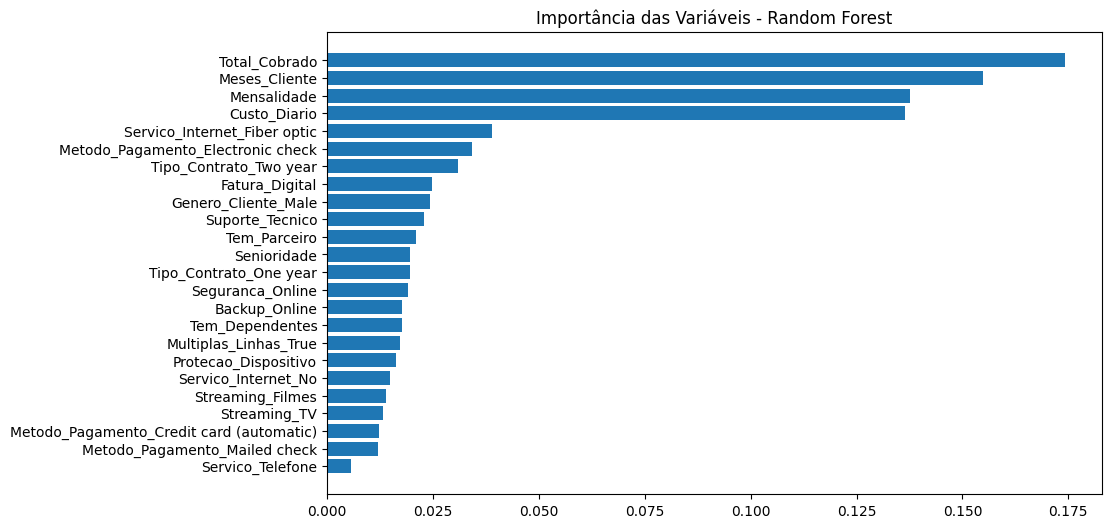

,Feature,Importance
6,Backup_Online,0.017721
2,Tem_Dependentes,0.017613
16,Multiplas_Linhas_True,0.017201
7,Protecao_Dispositivo,0.016380
18,Servico_Internet_No,0.014905
10,Streaming_Filmes,0.013983
9,Streaming_TV,0.013256
21,Metodo_Pagamento_Credit card (automatic),0.012308
23,Metodo_Pagamento_Mailed check,0.011959
4,Servico_Telefone,0.005688


In [9]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=51)

# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=51)
rf.fit(X_train, y_train)

# Importância das variáveis
importances = rf.feature_importances_
feature_names = X.columns

# Criando dataframe de importância
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest")
plt.show()


feat_imp.tail(10)


## ***O que os resultados mostram***
**Mais relevantes (alto peso)**

- Total_Cobrado, Meses_Cliente, Custo_Diario, Mensalidade → são os principais drivers.

- Servico_Internet_Fiber optic, Tipo_Contrato_Two year,   Metodo_Pagamento_Electronic check → também aparecem com impacto significativo.

**Peso intermediário**

- Genero_Cliente_Male, Fatura_Digital, Tipo_Contrato_One year → têm alguma influência, mas não são tão fortes.

**Candidatos a remoção**

 - Variáveis que ficaram com importância muito baixa (**não apareceram no top 10** ou têm valores próximos de zero).


 Analisando o grafico, podemos perceber que a maioria das colunas para remoção fazem parte de um conjunto de outras variaveis, então vamos partir para uma analise com o VIF

In [10]:
#ViF
X = df_encoded.drop('Churn', axis=1)
X_const = add_constant(X)

# Calculando VIF
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]

vif.sort_values(by="VIF", ascending=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
12,Mensalidade,inf
14,Custo_Diario,inf
17,Servico_Internet_Fiber optic,148.263480
18,Servico_Internet_No,104.220019
4,Servico_Telefone,34.862059
10,Streaming_Filmes,24.109486
9,Streaming_TV,24.056876
13,Total_Cobrado,10.541130
3,Meses_Cliente,7.304521
16,Multiplas_Linhas_True,7.274304


## **O que os valores indicam**
- Mensalidade e Custo_Diario → deram inf (infinito), o que significa que são praticamente combinações lineares perfeitas de outras variáveis.

- Servico_Internet_Fiber optic e Servico_Internet_No → VIF altíssimo (>100), indicando redundância entre si (são variáveis dummies exclusivas).

- Total_Cobrado e Meses_Cliente → valores elevados, mas não extremos, sugerindo correlação forte.

- Variáveis como Genero_Cliente_Male, Fatura_Digital, Senioridade → VIF baixo, sem problema.

**O que irei remover?**
- Custo_Diario
- Servico_Internet_No
- Total_Cobrado (já depende de Mensalidade e Meses_Cliente)

In [11]:
df_encoded_tratrado = df_encoded.drop(columns=['Custo_Diario', 'Servico_Internet_No', 'Total_Cobrado'])

# Começando o ML

In [12]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=51, stratify=y
)

smote = SMOTE(random_state=51)
X_res, y_res = smote.fit_resample(X_train, y_train)


In [13]:
def avaliar_modelos(modelos, X_res, y_res, X_test, y_test):
    resultados = []
    for nome, modelo in modelos.items():
        modelo.fit(X_res, y_res)
        y_pred = modelo.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        y_prob = modelo.predict_proba(X_test)[:,1] if hasattr(modelo, "predict_proba") else None

        resultados.append({
            'Modelo': nome,
            'Accuracy': modelo.score(X_test, y_test),
            'Recall (Churn)': report['1']['recall'],
            'Precision (Churn)': report['1']['precision'],
            'F1 (Churn)': report['1']['f1-score']
        })
    return pd.DataFrame(resultados)

In [14]:
# Hiperparâmetros Random Forest
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

rf = GridSearchCV(
    RandomForestClassifier(random_state=51),
    param_grid=param_grid,
    cv=3, scoring='f1', n_jobs=-1
)

# Hiperparâmetros XGBoost
param_dist = {
    'n_estimators': [200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}

xgb = RandomizedSearchCV(
    XGBClassifier(random_state=51, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=15, cv=3, scoring='f1', random_state=51, n_jobs=-1
)



modelos = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=51),
    "Random Forest": rf,
    "XGBoost": xgb}

avaliar_modelos(modelos, X_res, y_res, X_test, y_test)

,Modelo,Accuracy,Recall (Churn),Precision (Churn),F1 (Churn)
0,Dummy,0.734501,0.000000,0.000000,0.000000
1,Random Forest,0.583403,0.620321,0.550633,0.583403
2,XGBoost,0.619651,0.696970,0.557775,0.619651


In [15]:
X = df_encoded_tratrado.drop('Churn', axis=1)
y = df_encoded_tratrado['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=51, stratify=y
)

smote = SMOTE(random_state=51)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [16]:
modelos = {
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=51),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=51),

    "KNN": KNeighborsClassifier(n_neighbors=5)
}

avaliar_modelos(modelos, X_res, y_res, X_test, y_test)

,Modelo,Accuracy,Recall (Churn),Precision (Churn),F1 (Churn)
0,Dummy,0.734501,0.000000,0.000000,0.000000
1,Logistic Regression,0.748699,0.764706,0.518116,0.617711
2,KNN,0.715097,0.729055,0.476135,0.576056


## Consolidar Métricas de Desempenho




In [17]:

modelos_set1 = {
    "Random Forest": rf,
    "XGBoost": xgb
}

modelos_set2 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=51),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


resultados_rf_xgb = avaliar_modelos(modelos_set1, X_res, y_res, X_test, y_test)
resultados_lr_knn = avaliar_modelos(modelos_set2, X_res, y_res, X_test, y_test)


df_comparativo_final = pd.concat([resultados_rf_xgb, resultados_lr_knn], ignore_index=True)

df_comparativo_final = df_comparativo_final[['Modelo', 'Recall (Churn)', 'F1 (Churn)']]

df_comparativo_final = df_comparativo_final.sort_values(by='Recall (Churn)', ascending=False).reset_index(drop=True)

print("Tabela Comparativa Final de Desempenho:")
display(df_comparativo_final)

Tabela Comparativa Final de Desempenho:


,Modelo,Recall (Churn),F1 (Churn)
0,Logistic Regression,0.764706,0.617711
1,KNN,0.729055,0.576056
2,XGBoost,0.691622,0.614897
3,Random Forest,0.614973,0.577889


In [18]:
# 1. Logistic Regression Coefficients
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=51)
lr_model.fit(X_res, y_res)
lr_coeffs = pd.DataFrame({'Feature': X_res.columns, 'Coefficient': lr_model.coef_[0]})
lr_coeffs['Abs_Coefficient'] = lr_coeffs['Coefficient'].abs()
lr_coeffs = lr_coeffs.sort_values(by='Abs_Coefficient', ascending=False)

# 2. XGBoost Feature Importance
xgb_best = xgb.best_estimator_
xgb_importances = pd.DataFrame({'Feature': X_res.columns, 'Importance_XGB': xgb_best.feature_importances_})

# 3. Random Forest Feature Importance
rf_best = rf.best_estimator_
rf_importances = pd.DataFrame({'Feature': X_res.columns, 'Importance_RF': rf_best.feature_importances_})

# Consolidando drivers
drivers = lr_coeffs[['Feature', 'Coefficient']].merge(xgb_importances, on='Feature').merge(rf_importances, on='Feature')

print("Top Drivers Logistic Regression (Coefficients):")
display(lr_coeffs.head(10))

print("\nTop Drivers XGBoost (Importance):")
display(xgb_importances.sort_values(by='Importance_XGB', ascending=False).head(10))

print("\nTop Drivers Random Forest (Importance):")
display(rf_importances.sort_values(by='Importance_RF', ascending=False).head(10))

Top Drivers from Logistic Regression (Coefficients):


,Feature,Coefficient,Abs_Coefficient
12,Mensalidade,2.193427,2.193427
4,Servico_Telefone,-1.619730,1.619730
17,Tipo_Contrato_Two year,-1.528882,1.528882
5,Seguranca_Online,-1.252138,1.252138
15,Servico_Internet_Fiber optic,-1.089447,1.089447
8,Suporte_Tecnico,-1.030605,1.030605
16,Tipo_Contrato_One year,-0.961625,0.961625
6,Backup_Online,-0.740232,0.740232
18,Metodo_Pagamento_Credit card (automatic),-0.635370,0.635370
3,Meses_Cliente,-0.559089,0.559089



Top Drivers from XGBoost (Importance):


,Feature,Importance_XGB
17,Tipo_Contrato_Two year,0.482197
16,Tipo_Contrato_One year,0.191293
15,Servico_Internet_Fiber optic,0.087692
4,Servico_Telefone,0.025472
5,Seguranca_Online,0.020919
8,Suporte_Tecnico,0.019312
3,Meses_Cliente,0.015346
6,Backup_Online,0.013870
2,Tem_Dependentes,0.013802
12,Mensalidade,0.013715



Top Drivers from Random Forest (Importance):


,Feature,Importance_RF
3,Meses_Cliente,0.218411
12,Mensalidade,0.212789
17,Tipo_Contrato_Two year,0.082054
15,Servico_Internet_Fiber optic,0.059625
16,Tipo_Contrato_One year,0.045442
5,Seguranca_Online,0.038613
19,Metodo_Pagamento_Electronic check,0.034276
8,Suporte_Tecnico,0.032736
13,Genero_Cliente_Male,0.029432
11,Fatura_Digital,0.027170


# Relatório de Retenção de Clientes - Análise de Churn

## 1. Desempenho dos Modelos

Com base nos testes realizados, consolidamos as métricas de Recall e F1-Score para identificar o modelo mais eficaz na detecção de clientes em risco de evasão (Churn). O Recall é nossa métrica prioritária, pois reflete a capacidade do modelo de encontrar o maior número possível de clientes que realmente pretendem sair.

| Modelo | Recall (Churn) | F1 (Churn) |
| :--- | :---: | :---: |
| Logistic Regression | 0.7647 | 0.6177 |
| KNN | 0.7291 | 0.5761 |
| XGBoost | 0.6916 | 0.6149 |
| Random Forest | 0.6150 | 0.5779 |

**Conclusão do Modelo:** A **Regressão Logística** apresentou o melhor Recall (76,4%), sendo o modelo recomendado para a estratégia de retenção inicial.

## 2. Perfil do Cliente Propenso ao Churn (Drivers)

Através da análise de coeficientes e importância de variáveis, identificamos os principais fatores que impulsionam o cancelamento:

*   **Tipo de Contrato:** Clientes com contratos de curto prazo (mês a mês) têm altíssima propensão ao churn. Contratos de um ou dois anos são os maiores inibidores de evasão.
*   **Serviço de Internet:** Clientes com Fibra Óptica apresentam uma taxa de cancelamento proporcionalmente maior, possivelmente devido a problemas técnicos ou preço.
*   **Método de Pagamento:** O uso de 'Electronic Check' (cheque eletrônico) está fortemente correlacionado ao churn, enquanto pagamentos automáticos (cartão de crédito/débito) aumentam a retenção.
*   **Encargos Financeiros:** Mensalidades elevadas e baixo tempo de casa (Meses_Cliente) são indicadores críticos.

## 3. Recomendações Estratégicas

Com base nos drivers identificados, propomos as seguintes ações:

1.  **Incentivo à Fidelidade:** Criar campanhas de desconto agressivas para migrar clientes de contratos 'Month-to-month' para contratos anuais ou bianuais.
2.  **Qualidade na Fibra Óptica:** Priorizar o suporte técnico e realizar auditorias de qualidade na rede de Fibra Óptica para reduzir a insatisfação específica deste segmento.
3.  **Automação de Pagamentos:** Oferecer benefícios (ex: cashback ou bônus de dados) para clientes que alterarem o método de pagamento para débito automático ou cartão de crédito.
4.  **Atendimento Proativo:** Utilizar o score do modelo de Regressão Logística para sinalizar clientes de 'alto risco' com menos de 6 meses de contrato para uma consultoria de sucesso do cliente proativa.